In [ ]:
# ==============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
import gc
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge  # Ridge añade estabilidad numérica con L2 suave
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

path_parquet_1 = "/content/drive/MyDrive/Maestria Ingenieria y analitica de datos/semestre 4/proyecto de grado/fuentes de datos/base_finales/base_filtrada/"

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


In [ ]:
# ==============================================================================
# PASO 2: CARGA SELECTIVA DE VARIABLES
# ==============================================================================
selected_columns = [
    # Demográficas e individuales
    "estu_genero",
    "estu_fechanacimiento",
    "estu_horassemanatrabaja",
    "estu_dedicacioninternet",
    "estu_dedicacionlecturadiaria",
    # Socioeconómicas y familiares
    "fami_estratovivienda",
    "fami_educacionmadre",
    "estu_inse_individual",
    "estu_nse_establecimiento",
    "fami_personashogar",
    "fami_cuartoshogar",
    "fami_numlibros",
    "fami_trabajolabormadre",
    "fami_trabajolaborpadre",
    # Bienes para índice
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneconsolavideojuegos",
    "fami_tienehornomicroogas",
    "fami_tieneinternet",
    "fami_tienelavadora",
    "fami_tienemotocicleta",
    "fami_tieneserviciotv",
    # Alimentos para índice
    "fami_comecarnepescadohuevo",
    "fami_comecerealfrutoslegumbre",
    "fami_comelechederivados",
    # Institucionales y territoriales
    "cole_naturaleza",
    "cole_area_ubicacion",
    "cole_calendario",
    "cole_jornada",
    "cole_caracter",
    "cole_cod_mcpio_ubicacion",
    "estu_cod_reside_depto",
    "estu_cod_reside_mcpio",
    "periodo",
    "punt_global",
]

df = pd.read_parquet(path_parquet_1, columns=selected_columns)
print(f"Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas.")

Dataset cargado: 861,251 filas y 35 columnas.


In [ ]:
# ==============================================================================
# PASO 3: INGENIERÍA DE CARACTERÍSTICAS E ÍNDICES SINTÉTICOS
# ==============================================================================
# 3.1 Limpieza variable objetivo
df["punt_global"] = pd.to_numeric(df["punt_global"], errors="coerce")
df.dropna(subset=["punt_global"], inplace=True)

# 3.2 Cálculo de edad
df["ano_examen"] = df["periodo"].astype(str).str[:4].astype(int)
df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"], format="%d/%m/%Y", errors="coerce"
)
df["estu_edad"] = df["ano_examen"] - df["estu_fechanacimiento"].dt.year
df = df[(df["estu_edad"] >= 10) & (df["estu_edad"] <= 80)].copy()
df.drop(columns=["estu_fechanacimiento", "ano_examen", "periodo"], inplace=True)

# 3.3 Índice de Bienes (0 a 8)
cols_bienes = [
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneconsolavideojuegos",
    "fami_tienehornomicroogas",
    "fami_tieneinternet",
    "fami_tienelavadora",
    "fami_tienemotocicleta",
    "fami_tieneserviciotv",
]
for col in cols_bienes:
    df[col + "_bin"] = (df[col].astype(str).str.upper() == "SI").astype(
        np.int8
    )

df["indice_bienes"] = (
    df[[c + "_bin" for c in cols_bienes]].sum(axis=1).astype(np.int8)
)
df.drop(
    columns=cols_bienes + [c + "_bin" for c in cols_bienes], inplace=True
)

# 3.4 Índice de Consumo Alimentario (0 a 9)
map_consumo = {
    "Nunca o rara vez comemos eso": 0,
    "1 o 2 veces por semana": 1,
    "3 a 5 veces por semana": 2,
    "Todos o casi todos los días": 3,
}
cols_consumo = [
    "fami_comecarnepescadohuevo",
    "fami_comecerealfrutoslegumbre",
    "fami_comelechederivados",
]
for col in cols_consumo:
    df[col + "_num"] = df[col].map(map_consumo).fillna(0).astype(np.int8)

df["indice_consumo"] = (
    df[[c + "_num" for c in cols_consumo]].sum(axis=1).astype(np.int8)
)
df.drop(
    columns=cols_consumo + [c + "_num" for c in cols_consumo], inplace=True
)

print(
    f"Registros depurados listos para modelar: {df.shape[0]:,} observaciones."
)

Registros depurados listos para modelar: 859,949 observaciones.


In [ ]:
# ==============================================================================
# PASO 4: PREPROCESAMIENTO, ESCALAMIENTO Y PARTICIÓN TRAIN/TEST
# ==============================================================================
# 4.1 Definición de jerarquías ordinales
orden_educacion = [
    "Ninguno",
    "Primaria incompleta",
    "Primaria completa",
    "Secundaria (Bachillerato) incompleta",
    "Secundaria (Bachillerato) completa",
    "Técnica o tecnológica incompleta",
    "Técnica o tecnológica completa",
    "Educación profesional incompleta",
    "Educación profesional completa",
    "Postgrado",
]
orden_horas_trabajo = [
    "0",
    "Menos de 10 horas",
    "Entre 11 y 20 horas",
    "Entre 21 y 30 horas",
    "Más de 30 horas",
]
orden_internet = [
    "No Navega Internet",
    "30 minutos o menos",
    "Entre 30 y 60 minutos",
    "Entre 1 y 3 horas",
    "Más de 3 horas",
]
orden_lectura = [
    "No leo por entretenimiento",
    "30 minutos o menos",
    "Entre 30 y 60 minutos",
    "Entre 1 y 2 horas",
    "Más de 2 horas",
]
orden_estrato = [
    "Sin Estrato",
    "Estrato 1",
    "Estrato 2",
    "Estrato 3",
    "Estrato 4",
    "Estrato 5",
    "Estrato 6",
]
orden_personas_hogar = ["1 a 2", "3 a 4", "5 a 6", "7 a 8", "9 o más"]
orden_cuartos = ["Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis o más"]
orden_libros = [
    "0 A 10 LIBROS",
    "11 A 25 LIBROS",
    "26 A 100 LIBROS",
    "MÁS DE 100 LIBROS",
]

ordinal_cols = [
    "fami_educacionmadre",
    "estu_horassemanatrabaja",
    "estu_dedicacioninternet",
    "estu_dedicacionlecturadiaria",
    "fami_estratovivienda",
    "fami_personashogar",
    "fami_cuartoshogar",
    "fami_numlibros",
]
ordinal_categories = [
    orden_educacion,
    orden_horas_trabajo,
    orden_internet,
    orden_lectura,
    orden_estrato,
    orden_personas_hogar,
    orden_cuartos,
    orden_libros,
]

# Variables nominales (agrupamos las de baja frecuencia para evitar explosión de columnas)
nominal_cols = [
    "estu_genero",
    "fami_trabajolabormadre",
    "fami_trabajolaborpadre",
    "cole_naturaleza",
    "cole_area_ubicacion",
    "cole_calendario",
    "cole_jornada",
    "cole_caracter",
    "cole_cod_mcpio_ubicacion",
    "estu_cod_reside_depto",
    "estu_cod_reside_mcpio",
]

numeric_cols = [
    "estu_edad",
    "estu_inse_individual",
    "estu_nse_establecimiento",
    "indice_bienes",
    "indice_consumo",
]

# Pipelines por tipo de dato con escalamiento estándar
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
        ("scaler", StandardScaler()),
    ]
)

nominal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=True,
                min_frequency=0.01,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("ord", ordinal_pipeline, ordinal_cols),
        ("nom", nominal_pipeline, nominal_cols),
    ]
)

# Separación X / y y Partición 80/20
X = df.drop(columns=["punt_global"])
y = df["punt_global"].astype(np.float32)

del df
gc.collect()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Conjunto de Entrenamiento: {X_train.shape[0]:,} registros")
print(f"Conjunto de Prueba:        {X_test.shape[0]:,} registros")

Conjunto de Entrenamiento: 687,959 registros
Conjunto de Prueba:        171,990 registros


In [ ]:
# ==============================================================================
# PASO 5: ENTRENAMIENTO Y EVALUACIÓN DE REGRESIÓN LINEAL (RIDGE BASELINE)
# ==============================================================================
# Usamos Ridge con regularización mínima (alpha=1.0) para garantizar estabilidad numérica
lr_model = Ridge(alpha=1.0, random_state=42)

lr_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", lr_model)]
)

print("Entrenando Regresión Lineal Múltiple...")
t0 = time.time()
lr_pipeline.fit(X_train, y_train)
print(f"Entrenamiento completado en {(time.time() - t0):.2f} segundos.")

# Predicciones
y_pred_train = lr_pipeline.predict(X_train)
y_pred_test = lr_pipeline.predict(X_test)

# Métricas
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("\n--- MÉTRICAS DE EVALUACIÓN (TRAIN) ---")
print(f"R²:   {r2_train:.4f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE:  {mae_train:.2f}")

print("\n--- MÉTRICAS DE EVALUACIÓN (TEST) ---")
print(f"R²:   {r2_test:.4f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE:  {mae_test:.2f}")

Entrenando Regresión Lineal Múltiple...
Entrenamiento completado en 22.42 segundos.


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



--- MÉTRICAS DE EVALUACIÓN (TRAIN) ---
R²:   0.3638
RMSE: 39.90
MAE:  32.10

--- MÉTRICAS DE EVALUACIÓN (TEST) ---
R²:   0.3627
RMSE: 39.97
MAE:  32.14


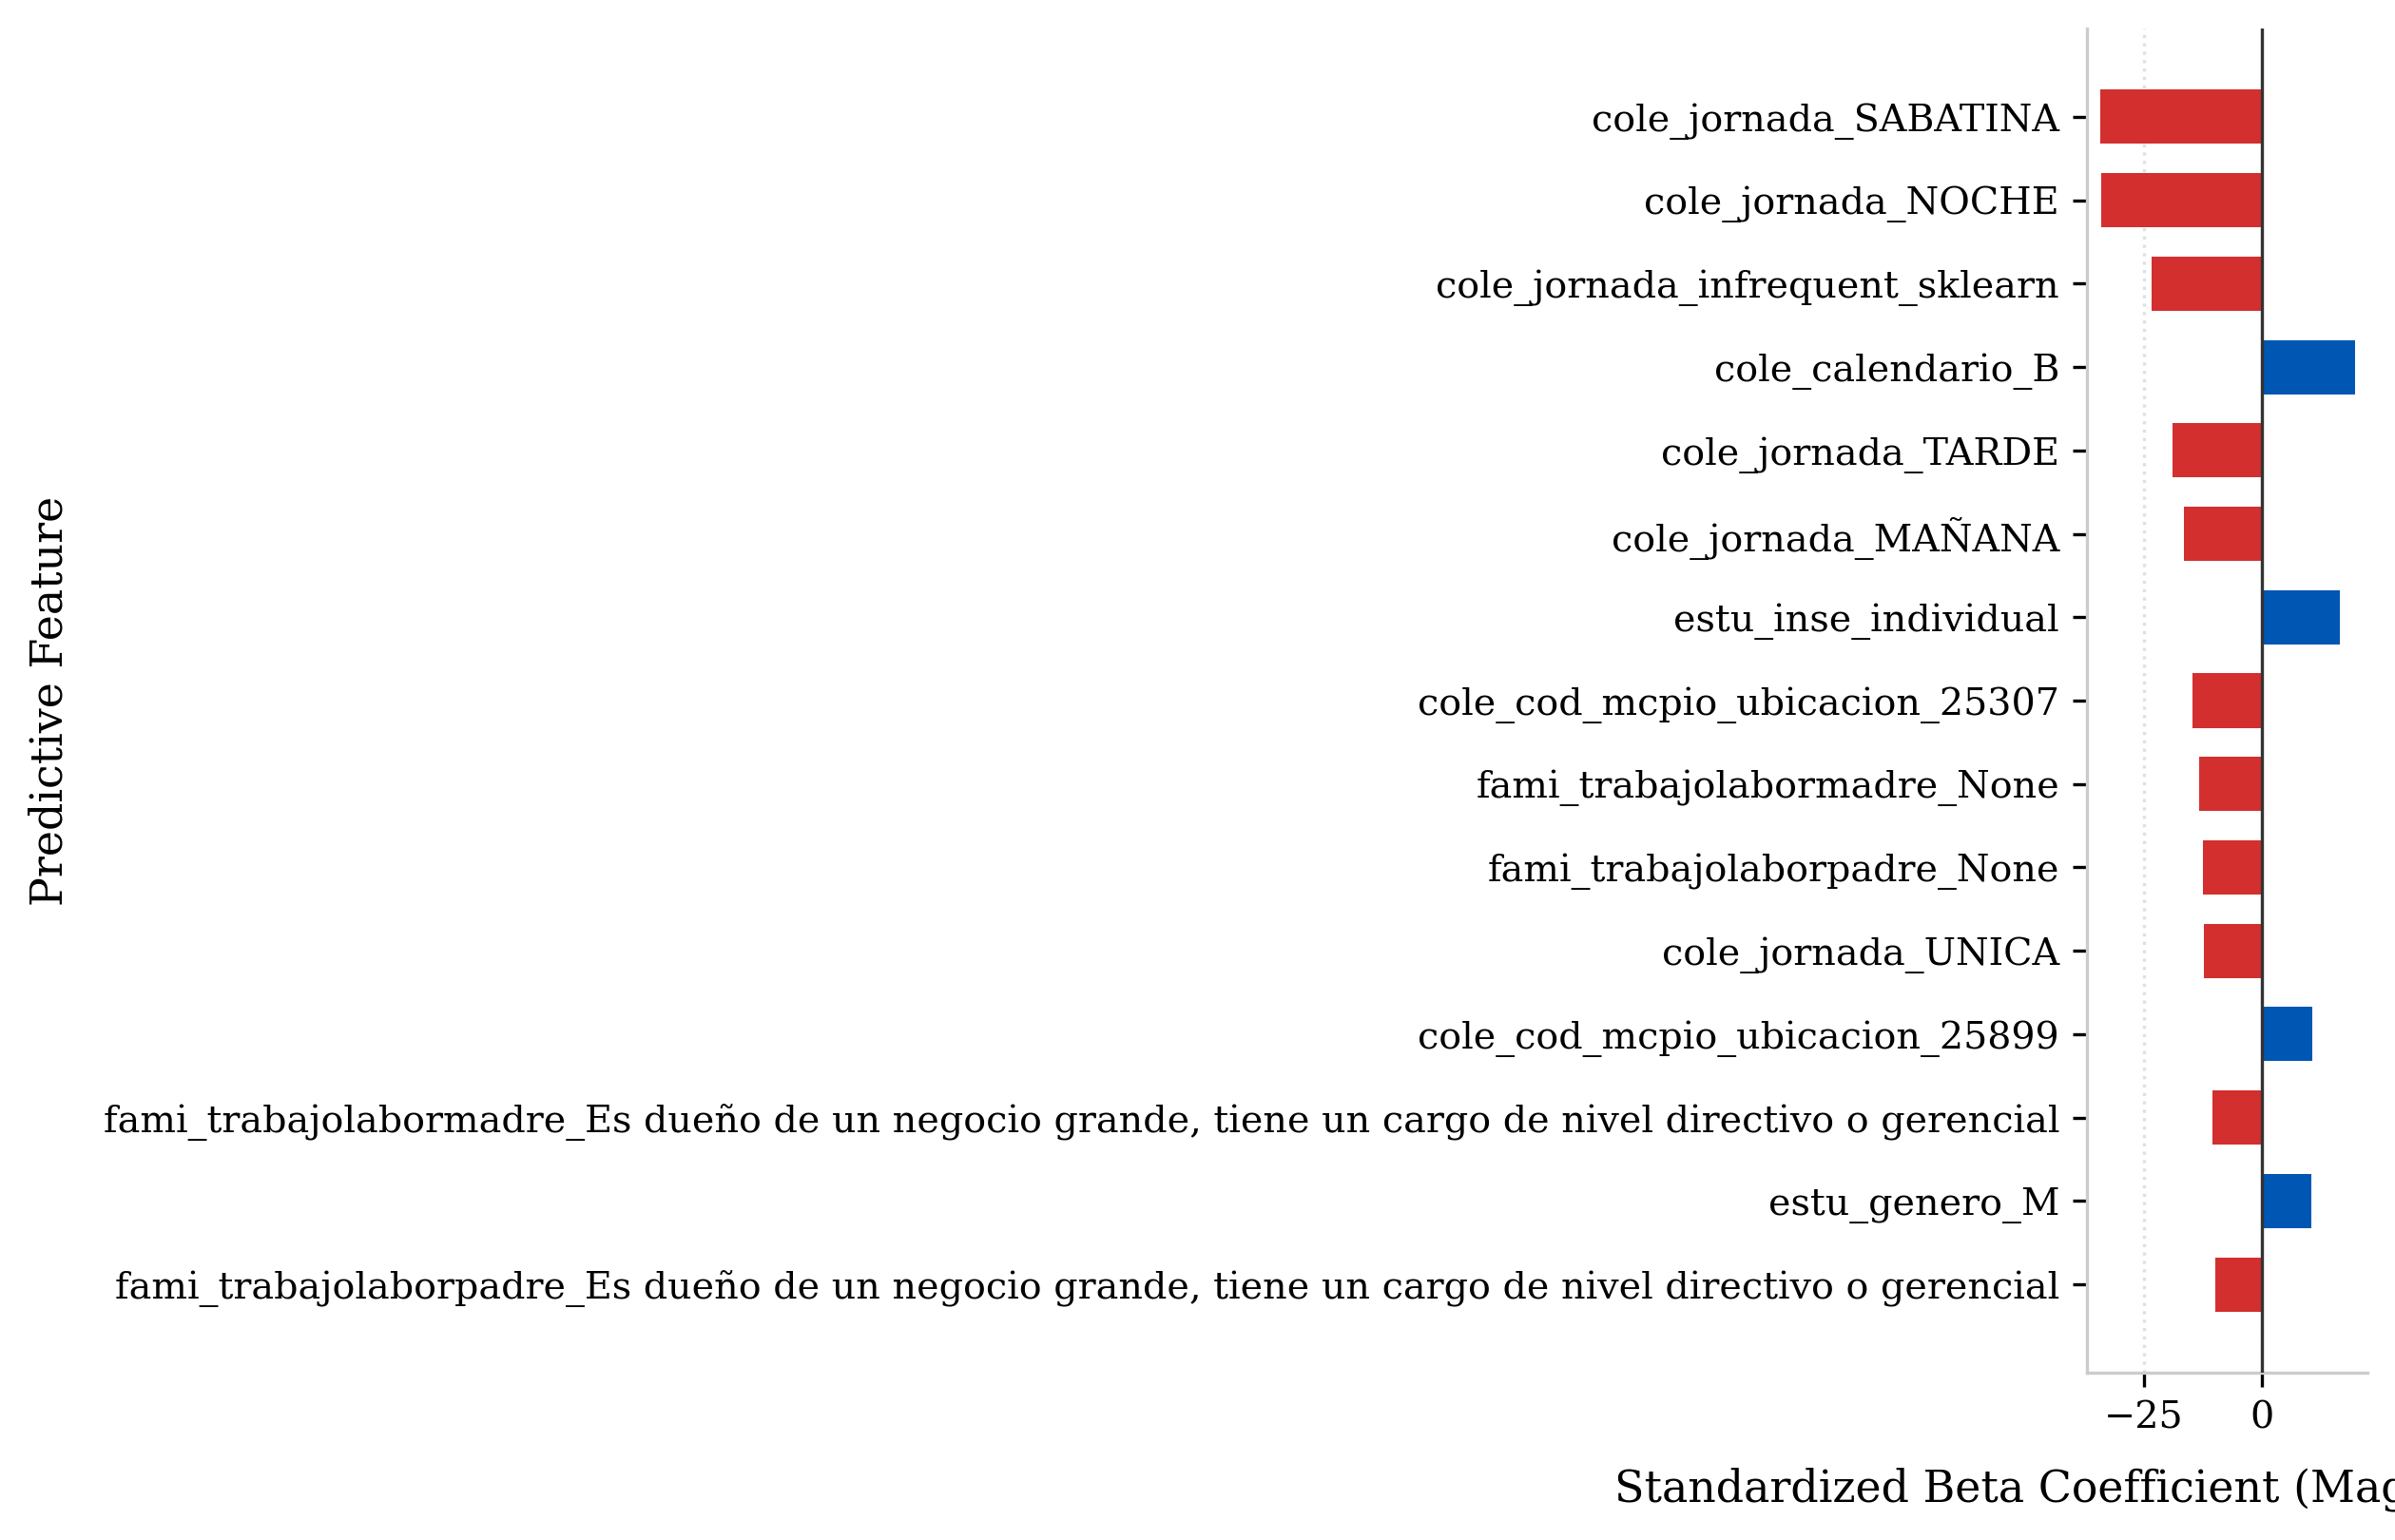


--- TOP 15 COEFICIENTES CON MAYOR IMPACTO ---
                                                                                            Feature  Coefficient
                                                                              cole_jornada_SABATINA   -34.308718
                                                                                 cole_jornada_NOCHE   -34.028697
                                                                    cole_jornada_infrequent_sklearn   -23.484046
                                                                                  cole_calendario_B    19.556129
                                                                                 cole_jornada_TARDE   -19.011905
                                                                                cole_jornada_MAÑANA   -16.539873
                                                                               estu_inse_individual    16.326769
                                                 

In [ ]:
# ==============================================================================
# PASO 6: EXTRACCIÓN Y GRAFICACIÓN DE COEFICIENTES ESTANDARIZADOS
# ==============================================================================
# Recuperar nombres de variables codificadas
ohe_names = (
    lr_pipeline.named_steps["preprocessor"]
    .named_transformers_["nom"]
    .named_steps["onehot"]
    .get_feature_names_out(nominal_cols)
)
all_feature_names = numeric_cols + ordinal_cols + list(ohe_names)

coefs = lr_pipeline.named_steps["regressor"].coef_

df_coefs = pd.DataFrame(
    {"Feature": all_feature_names, "Coefficient": coefs}
)
df_coefs["Abs_Coef"] = df_coefs["Coefficient"].abs()
df_coefs = df_coefs.sort_values(by="Abs_Coef", ascending=False).reset_index(
    drop=True
)

top_15_coefs = df_coefs.head(15).copy()

# Configuración visual JEDM
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 11,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
    }
)

fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=300)

y_pos = np.arange(len(top_15_coefs))
colors = [
    "#0056b3" if c >= 0 else "#d32f2f" for c in top_15_coefs["Coefficient"]
]

ax.barh(
    y_pos,
    top_15_coefs["Coefficient"],
    align="center",
    color=colors,
    edgecolor="none",
    height=0.65,
    zorder=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_15_coefs["Feature"])
ax.invert_yaxis()

ax.axvline(0, color="#333333", linestyle="-", linewidth=0.8, zorder=4)
ax.set_xlabel("Standardized Beta Coefficient (Magnitude & Direction)", labelpad=8)
ax.set_ylabel("Predictive Feature", labelpad=8)

ax.xaxis.grid(True, linestyle=":", alpha=0.6, color="#CCCCCC", zorder=0)
ax.yaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=300, bbox_inches="tight")
plt.savefig("lr_coefficients.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("\n--- TOP 15 COEFICIENTES CON MAYOR IMPACTO ---")
print(
    top_15_coefs[["Feature", "Coefficient"]].to_string(index=False)
)